# Imports


In [134]:
import warnings  #it handle warning messages
warnings.filterwarnings("ignore") #it will not display all the warning messages

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, QuantileTransformer, PowerTransformer
from sklearn.metrics import mean_squared_error, r2_score

'''
StandardScaler: Centers data around mean 0 and scales by standard deviation.

MinMaxScaler: Scales values to a specified range, commonly 0-1.

RobustScaler: Uses median and interquartile range; less sensitive to outliers.

MaxAbsScaler: Scales by maximum absolute value.

QuantileTransformer: Transforms data based on its quantiles.

PowerTransformer: Applies a power transformation to make data more Gaussian-like.
'''


'\nStandardScaler: Centers data around mean 0 and scales by standard deviation.\n\nMinMaxScaler: Scales values to a specified range, commonly 0-1.\n\nRobustScaler: Uses median and interquartile range; less sensitive to outliers.\n\nMaxAbsScaler: Scales by maximum absolute value.\n\nQuantileTransformer: Transforms data based on its quantiles.\n\nPowerTransformer: Applies a power transformation to make data more Gaussian-like.\n'

# Load


In [135]:
DATA_DIR = Path("data") # folder next to this notebook with the two plant csvs
generation = pd.read_csv(DATA_DIR / "Plant_1_Generation_Data.csv") # inverter-level power
weather = pd.read_csv(DATA_DIR / "Plant_1_Weather_Sensor_Data.csv") # plant-level weather sensor

print("generation:")
print(generation.head())
print(len(generation), "generation rows")

print("weather:")
print(weather.head())
print(len(weather), "weather rows")


generation:
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
68778 generation rows
weather:
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe           

# Understand Data


In [136]:
print("generation dtypes:")
print(generation.dtypes)
print("weather dtypes:")
print(weather.dtypes)

print("generation nulls:")
print(generation.isna().sum())
print("weather nulls:")
print(weather.isna().sum())

print("generation plant ids:", generation["PLANT_ID"].unique())
print("weather plant ids:", weather["PLANT_ID"].unique())
print("inverters:", generation["SOURCE_KEY"].nunique())
print("weather sensors:", weather["SOURCE_KEY"].nunique())

print(generation[["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]].describe())
print(weather[["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]].describe())


generation dtypes:
DATE_TIME          str
PLANT_ID         int64
SOURCE_KEY         str
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object
weather dtypes:
DATE_TIME                  str
PLANT_ID                 int64
SOURCE_KEY                 str
AMBIENT_TEMPERATURE    float64
MODULE_TEMPERATURE     float64
IRRADIATION            float64
dtype: object
generation nulls:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
weather nulls:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64
generation plant ids: [4135001]
weather plant ids: [4135001]
inverters: 22
weather sensors: 1
           DC_POWER      AC_POWER   DAILY_YIELD   TOTAL_YIELD
count  68778.000000  68778.000000  68778.000000  6.877800e+04
mean    3147.426211    307.802752   3295.968

# Data Cleaning


merged rows: 68774
AC_POWER IQR outliers: 0
AMBIENT_TEMPERATURE IQR outliers: 0
MODULE_TEMPERATURE IQR outliers: 0
IRRADIATION IQR outliers: 44
IRRADIATION outlier rows: 44
          DATE_TIME      SOURCE_KEY  IRRADIATION
2020-05-30 12:00:00 1BY6WEcLGh8j5v7     1.151102
2020-05-30 12:00:00 1IF53ai7Xc0U56Y     1.151102
2020-05-30 12:00:00 3PZuoBAID5Wc2HD     1.151102
2020-05-30 12:00:00 7JYdWkrLSPkdwr4     1.151102
2020-05-30 12:00:00 McdE0feGgRqW7Ca     1.151102
2020-05-30 12:00:00 VHMLBKoKgIrUVDU     1.151102
2020-05-30 12:00:00 WRmjgnKYAwPKWDb     1.151102
2020-05-30 12:00:00 YxYtjZvoooNbGkE     1.151102
2020-05-30 12:00:00 ZnxXDlPa8U1GXgE     1.151102
2020-05-30 12:00:00 ZoEaEvLYb1n2sOq     1.151102
2020-05-30 12:00:00 adLQvlD726eNBSB     1.151102
2020-05-30 12:00:00 bvBOhCH3iADSZry     1.151102
2020-05-30 12:00:00 iCRJl6heRkivqQ3     1.151102
2020-05-30 12:00:00 ih0vzX44oOqAx2f     1.151102
2020-05-30 12:00:00 pkci93gMrogZuBj     1.151102
2020-05-30 12:00:00 rGa61gmuvPhdLxV     1.1

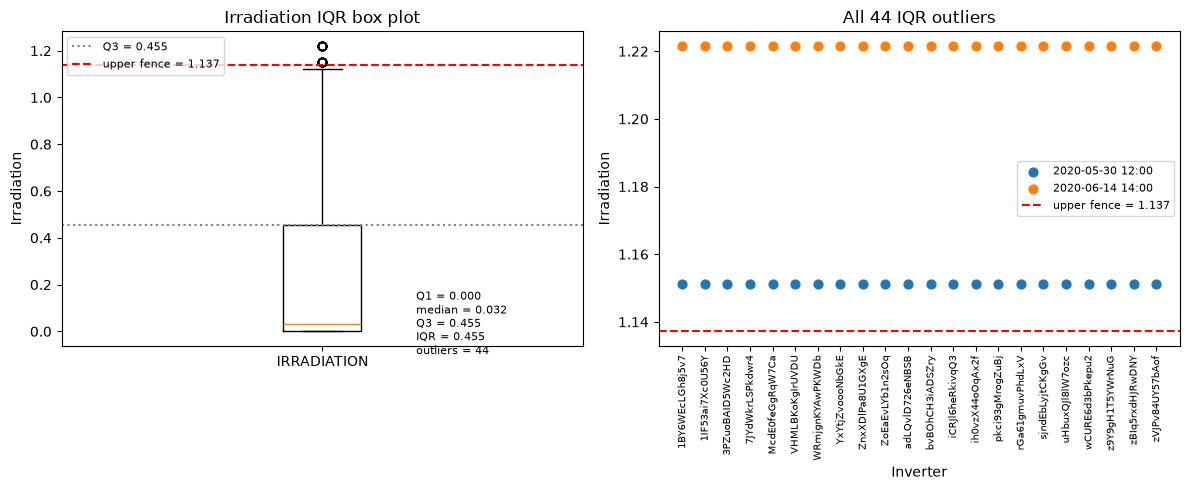

   DATE_TIME       SOURCE_KEY  AC_POWER  AMBIENT_TEMPERATURE  \
0 2020-05-15  1BY6WEcLGh8j5v7       0.0            25.184316   
1 2020-05-15  1IF53ai7Xc0U56Y       0.0            25.184316   
2 2020-05-15  3PZuoBAID5Wc2HD       0.0            25.184316   
3 2020-05-15  7JYdWkrLSPkdwr4       0.0            25.184316   
4 2020-05-15  McdE0feGgRqW7Ca       0.0            25.184316   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.857507          0.0  
2           22.857507          0.0  
3           22.857507          0.0  
4           22.857507          0.0  
clean rows: 68774
history: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00 
days: 33


In [137]:
# Incorrect data types: generation dates are like 15-05-2020 00:00, weather dates are like 2020-05-15 00:00:00
generation["DATE_TIME"] = pd.to_datetime(generation["DATE_TIME"], dayfirst=True)
weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"])

# Inconsistent values: both files use SOURCE_KEY, but generation SOURCE_KEY is an inverter and weather SOURCE_KEY is the sensor. PLANT_ID is the same for every row, so it is not a feature.
# Data leakage: DC_POWER is almost a copy of AC_POWER (about 10x because of how this plant logged DC). DAILY_YIELD and TOTAL_YIELD are running totals of the power we want to predict. Using them would be cheating.
weather = weather.drop(columns=["SOURCE_KEY", "PLANT_ID"])
generation = generation.drop(columns=["PLANT_ID", "DC_POWER", "DAILY_YIELD", "TOTAL_YIELD"])

# Combine both tables on the timestamp so each inverter reading has the plant weather. Inner join drops timestamps that exist in only one file.
df = generation.merge(weather, on="DATE_TIME", how="inner")
print("merged rows:", len(df))

# Incorrect / inconsistent numbers: power and irradiation cannot be negative
df["AC_POWER"] = df["AC_POWER"].clip(lower=0)
df["IRRADIATION"] = df["IRRADIATION"].clip(lower=0)

# Outliers: IQR count only. Midday AC and irradiation spikes are real sun, so we do not clip them away.
for col in ["AC_POWER", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(col, "IQR outliers:", int(n_out))

# Box plot for irradiation only. Whiskers use 1.5*IQR; dots past the whiskers are the outliers.
q1 = df["IRRADIATION"].quantile(0.25)
q3 = df["IRRADIATION"].quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
median = df["IRRADIATION"].median()
irr_out = df.loc[(df["IRRADIATION"] < lo) | (df["IRRADIATION"] > hi), ["DATE_TIME", "SOURCE_KEY", "IRRADIATION"]]
print("IRRADIATION outlier rows:", len(irr_out))
print(irr_out.to_string(index=False)) # all 44 rows: 2 timestamps x 22 inverters

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df["IRRADIATION"], showfliers=True) # showfliers=True draws outlier dots
axes[0].set_xticklabels(["IRRADIATION"])
axes[0].set_ylabel("Irradiation")
axes[0].set_title("Irradiation IQR box plot")
axes[0].axhline(q3, color="grey", ls=":", label=f"Q3 = {q3:.3f}")
axes[0].axhline(hi, color="red", ls="--", label=f"upper fence = {hi:.3f}")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].text(
    1.18, median,
    f"Q1 = {q1:.3f}\nmedian = {median:.3f}\nQ3 = {q3:.3f}\nIQR = {iqr:.3f}\noutliers = {len(irr_out)}",
    va="center", fontsize=8,
)

# Same y stacked 22 times on a box plot, so plot every outlier row by inverter.
for t, g in irr_out.groupby("DATE_TIME"):
    axes[1].scatter(g["SOURCE_KEY"], g["IRRADIATION"], label=f"{t:%Y-%m-%d %H:%M}", s=40)
axes[1].axhline(hi, color="red", ls="--", label=f"upper fence = {hi:.3f}")
axes[1].set_title("All 44 IQR outliers")
axes[1].set_ylabel("Irradiation")
axes[1].set_xlabel("Inverter")
axes[1].tick_params(axis="x", rotation=90, labelsize=7)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

df = df.sort_values(["DATE_TIME", "SOURCE_KEY"]).reset_index(drop=True)
print(df.head())
print("clean rows:", len(df))
print("history:", df["DATE_TIME"].min(), "->", df["DATE_TIME"].max(), "\ndays:", (df["DATE_TIME"].max() - df["DATE_TIME"].min()).days)


# Feature Engineering


In [138]:
df = pd.get_dummies(df, columns=["SOURCE_KEY"], prefix="Inverter", drop_first=True) # Create dummy variables for each inverter

# Hour as a circle, Hour=23 and Hour=0 are neighbors, not far apart.
hour = df["DATE_TIME"].dt.hour + df["DATE_TIME"].dt.minute / 60.0 # decimal hour
hour_angle = 2 * np.pi * hour / 24.0 # 24 hours = one full circle (0 to 2π radians)
df["HourSin"] = np.sin(hour_angle)
df["HourCos"] = np.cos(hour_angle)

print(df.sample(n=5, random_state=42))

                DATE_TIME    AC_POWER  AMBIENT_TEMPERATURE  \
48910 2020-06-08 13:45:00  873.237500            30.200903   
45151 2020-06-06 18:30:00    0.000000            23.801898   
17954 2020-05-24 09:15:00  613.785714            27.404045   
51959 2020-06-10 00:15:00    0.000000            22.775156   
53225 2020-06-10 14:45:00   98.628571            26.491622   

       MODULE_TEMPERATURE  IRRADIATION  Inverter_1IF53ai7Xc0U56Y  \
48910           51.813019     0.823869                     False   
45151           23.067796     0.002115                      True   
17954           41.316923     0.418877                     False   
51959           20.823775     0.000000                     False   
53225           29.685520     0.063961                     False   

       Inverter_3PZuoBAID5Wc2HD  Inverter_7JYdWkrLSPkdwr4  \
48910                      True                     False   
45151                     False                     False   
17954                     False    

# Scale and split


In [139]:
y = df["AC_POWER"].astype(float) # target: AC power from the inverter
X = df.drop(columns=["DATE_TIME", "AC_POWER"]).astype(float) # all remaining columns are features
dates = df["DATE_TIME"]

feature_scaler = StandardScaler()  # z-score
# feature_scaler = MinMaxScaler()
# feature_scaler = RobustScaler()
# feature_scaler = MaxAbsScaler()
# feature_scaler = QuantileTransformer(output_distribution="normal")
# feature_scaler = PowerTransformer(method="yeo-johnson")

target_scaler = StandardScaler()  # z-score
# target_scaler = MinMaxScaler()
# target_scaler = RobustScaler()
# target_scaler = MaxAbsScaler()
# target_scaler = QuantileTransformer(output_distribution="normal")
# target_scaler = PowerTransformer(method="yeo-johnson")

# Feature engineering is already done, then we scale, so HourSin / HourCos / TempDiff get scaled too. Scale on the full table, then split. Assignment asks for scale before train/test split.
X_scaled = pd.DataFrame(feature_scaler.fit_transform(X), columns=X.columns, index=X.index)
y_scaled = pd.Series(
    target_scaler.fit_transform(y.to_numpy().reshape(-1, 1)).ravel(),
    index=y.index,
    name="AC_POWER",
)

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)
y_train = y.loc[X_train_scaled.index]
y_test = y.loc[X_test_scaled.index]

print("Training data:")
print(X_train_scaled.head())
print(y_train.head())

print("Testing data:")
print(X_test_scaled.head())
print(y_test.head())

print("Target values:")
print(y.tail())


Training data:
       AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  \
25371            -0.628677           -0.718424    -0.769361   
13363            -0.638939           -0.727774    -0.769361   
7417              0.673850            0.771855     0.597765   
32102             1.090328            1.626233     1.420976   
35727            -1.166012           -0.898289    -0.769361   

       Inverter_1IF53ai7Xc0U56Y  Inverter_3PZuoBAID5Wc2HD  \
25371                 -0.217922                 -0.217922   
13363                  4.588800                 -0.217922   
7417                  -0.217922                 -0.217922   
32102                 -0.217922                 -0.217922   
35727                 -0.217922                 -0.217922   

       Inverter_7JYdWkrLSPkdwr4  Inverter_McdE0feGgRqW7Ca  \
25371                  -0.21847                 -0.218141   
13363                  -0.21847                 -0.218141   
7417                   -0.21847                 -0.21814

# Linear regression


In [140]:
model = LinearRegression(fit_intercept=True) #fit_intercept=True means that the model will learn an intercept term (bias) in addition to the coefficients for the features. This allows the model to make predictions that are not constrained to pass through the origin (0,0) in the feature space. If set to False, the model will assume that the data is centered around the origin and will not learn an intercept term.
model.fit(X_train_scaled, y_train_scaled)
y_pred_scaled = model.predict(X_test_scaled)
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_pred = np.clip(y_pred, 0, None) # AC power cannot be negative

print("coefficients:", model.coef_) # The coefficients of the linear regression model i.e the weights assigned to each feature.
print("intercept:", model.intercept_) # The intercept term (bias) of the linear regression model. in easy words, it is the value of the target variable when all the features are equal to zero. It represents the baseline level of the target variable in the absence of any influence from the features.
print("MSE:", round(mean_squared_error(y_test, y_pred), 2)) #formula: MSE = (1/n) * Σ(actual - predicted)², where n is the number of observations. It measures the average squared difference between actual and predicted values. A lower MSE indicates better model performance, as it means the predictions are closer to the actual values.
print("R2:", round(r2_score(y_test, y_pred), 2)) #formula: R² = 1 - (Σ(actual - predicted)² / Σ(actual - mean(actual))²). It measures the proportion of variance in the target variable that is explained by the model. An R² value closer to 1 indicates a better fit, while a value closer to 0 indicates a poor fit.
print("Accuracy:", round(100 - 100 * np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)), 2)) # 100 minus WAPE. sklearn accuracy_score is for classification, so we use this for regression.


coefficients: [-0.01394913  0.02094591  0.92319639  0.01600587  0.0159366   0.01181836
  0.01543503  0.01584899  0.01253413  0.0126552   0.0145854   0.01171454
  0.01809338 -0.0028061   0.01472325  0.00984405  0.01318336  0.01307786
  0.01192158  0.01415624  0.01300061  0.01096189  0.01213004  0.01404403
 -0.01134841 -0.06530346]
intercept: -0.00013932032016810087
MSE: 2780.73
R2: 0.98
Accuracy: 92.02


# Visualize


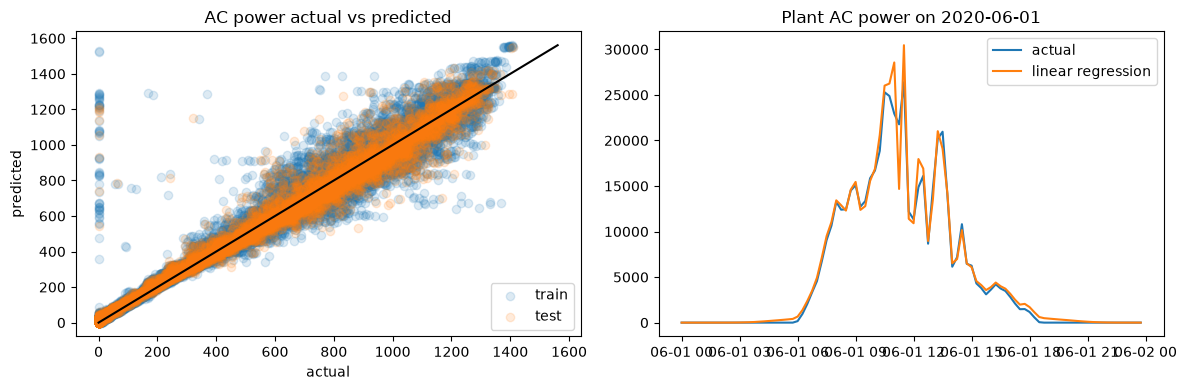

In [141]:
fitted = pd.Series(
    np.clip(target_scaler.inverse_transform(model.predict(X_scaled).reshape(-1, 1)).ravel(), 0, None),
    index=X.index,
)

sample_day = pd.Timestamp("2020-06-01")
day_mask = dates.dt.normalize() == sample_day
day = pd.DataFrame({
    "DATE_TIME": dates[day_mask].to_numpy(),
    "AC_POWER": y[day_mask].to_numpy(),
    "pred": fitted[day_mask].to_numpy(),
})
plant_day = day.groupby("DATE_TIME")[["AC_POWER", "pred"]].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train, fitted.loc[X_train_scaled.index], alpha=0.15, label="train")
axes[0].scatter(y_test, y_pred, alpha=0.15, label="test")
max_ac = max(y.max(), fitted.max())
axes[0].plot([0, max_ac], [0, max_ac], color="black")
axes[0].set_title("AC power actual vs predicted")
axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")
axes[0].legend()

axes[1].plot(plant_day.index, plant_day["AC_POWER"], label="actual")
axes[1].plot(plant_day.index, plant_day["pred"], label="linear regression")
axes[1].set_title("Plant AC power on 2020-06-01")
axes[1].legend()

plt.tight_layout()
plt.show()
